In [1]:
from matplotlib import pyplot as plt
import numpy as np
from PyCompOSE.compose.eos import Metadata,Table
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos
from RMFT.rmft_eos import RMFT_Finite_T
from scipy.interpolate import PchipInterpolator

In [2]:
n0 = 0.16
mn = 939 
hc = 197.3
n_0 = 0.16

In [3]:
md = Metadata(
    pairs = {
        0: ("e", "electron"),
        10: ("n", "neutro"),
        11: ("p", "proton"),
        4002: ("He4", "alpha particle"),
        3002: ("He3", "helium 3"),
        3001: ("H3", "tritium"),
        2001: ("H2", "deuteron")
    },
    quads = {
        999: ("N", "average nucleous")
    }
)

In [4]:
ls220 = Table(md)
bhb = Table(md)
sfho = Table(md)
bl = Table(md)
dd2 = Table(md)

ls220.read('EOS_Tables/LS220')
bhb.read('EOS_Tables/BHB')
sfho.read('EOS_Tables/SFHo')
bl.read('EOS_Tables/BL')
dd2.read('EOS_Tables/DD2')

In [6]:
ls220_beta = ls220.make_beta_eq_table()
bhb_beta = bhb.make_beta_eq_table()
sfho_beta = sfho.make_beta_eq_table()

In [7]:
ls220_beta.compute_cs2(floor=1e-6)
bhb_beta.compute_cs2(floor=1e-6)
sfho_beta.compute_cs2(floor=1e-6)
bl.compute_cs2(floor=1e-6)

/home/john/UW_PhD_Program/Projects/2025/RVSS_Slope_Parametrization/PyCompOSE/compose/eos.py:188: RuntimeWarning: divide by zero encountered in log
  dPdn = P*self.diff_wrt_nb(np.log(P))
/home/john/UW_PhD_Program/Projects/2025/RVSS_Slope_Parametrization/PyCompOSE/compose/eos.py:230: RuntimeWarning: invalid value encountered in subtract
  dQdn[1:-1,...] = (Q[2:,...] - Q[:-2,...])/(log_nb[2:] - log_nb[:-2])
/home/john/UW_PhD_Program/Projects/2025/RVSS_Slope_Parametrization/PyCompOSE/compose/eos.py:231: RuntimeWarning: invalid value encountered in subtract
  dQdn[0,...] = (Q[1,...] - Q[0,...])/(log_nb[1] - log_nb[0])
/home/john/UW_PhD_Program/Projects/2025/RVSS_Slope_Parametrization/PyCompOSE/compose/eos.py:188: RuntimeWarning: invalid value encountered in multiply
  dPdn = P*self.diff_wrt_nb(np.log(P))
/home/john/UW_PhD_Program/Projects/2025/RVSS_Slope_Parametrization/PyCompOSE/compose/eos.py:191: RuntimeWarning: divide by zero encountered in log
  dPdt = P*self.diff_wrt_t(np.log(P))
/hom

In [30]:
ls220_cs2 = ls220_beta.thermo["cs2"][:,0,0]
sfho_cs2 = sfho_beta.thermo["cs2"][:,0,0]
bhb_cs2 = bhb_beta.thermo["cs2"][:,0,0]
bl_cs2 = bl.thermo["cs2"][:].flatten()

ls220_nb = ls220_beta.nb
sfho_nb = sfho_beta.nb 
bhb_nb = bhb_beta.nb
bl_nb = bl.nb

ls220_mub = (ls220_beta.thermo["Q3"][:,0,0] + 1)*ls220.mn
sfho_mub = (sfho_beta.thermo["Q3"][:,0,0] + 1)*sfho.mn
bhb_mub = (bhb_beta.thermo["Q3"][:,0,0] + 1)*bhb.mn
bl_mub = (bl.thermo["Q3"].flatten() + 1)*bl.mn

In [37]:
alpha_ls220 = np.gradient(ls220_cs2,ls220_mub)
alpha_sfho = np.gradient(sfho_cs2,sfho_mub)
alpha_bhb = np.gradient(bhb_cs2,bhb_mub)
alpha_bl = np.gradient(bl_cs2,bl_mub)

Found matching n_t: 0.4267 n0
Bag constant set to -3.3613e+05 fm^-4
0.06895114108777152
0.07004927769210728
0.07116490355017775
0.07229829720109637
0.07344974162007423
0.07461952428907072
0.07580793726856935
0.07701527727049673
0.07824184573230279
0.07948794889222092
0.08075389786572672
0.08204000872321437
0.08334660256891019
0.08467400562104295
0.08602254929329103
0.08739257027752668
0.08878441062787815
0.09019841784613057
0.09163494496848698
0.09309435065371116
0.09457699927267418
0.09608326099932715
0.09761351190312287
0.09916813404290924
0.10074751556231827
0.10235205078667425
0.10398214032144502
0.10563819115226161
0.10732061674653057
0.10902983715666466
0.11076627912495768
0.11253037619012952
0.11432256879556808
0.11614330439929503
0.1179930375856831
0.11987223017895235
0.12178135135847427
0.12372087777591208
0.1256912936742267
0.12769309100857804
0.12972676956915177
0.1317928371059424
0.13389180945552345
0.13602421066983686
0.13819057314703329
0.1403914377643965
0.14262735401338

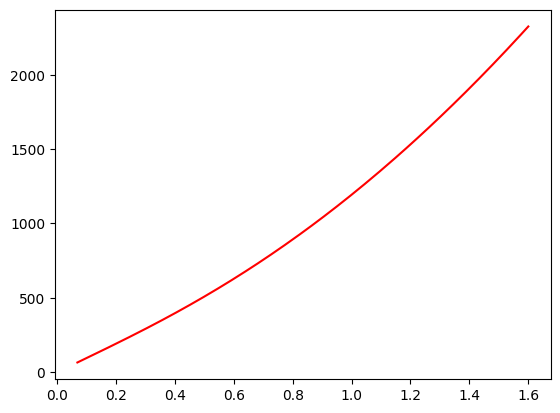

mu_b jump at transition: 0.086 MeV (should be near 0)
Found matching n_t: 0.3150 n0
Bag constant set to 3.1390e+05 fm^-4
0.050910504626520255
0.05180021777998812
0.05270547958105359
0.05362656175824081
0.0545637407888079
0.05551729798173589
0.05648751956216813
0.057474696757325104
0.05847912588392094
0.059501108437107514
0.0605409511809729
0.061598966240621486
0.06267547119586318
0.06377078917653996
0.06488524895951835
0.06601918506737708
0.06717293786881912
0.06834685368083869
0.06954128487267389
0.07075658997157569
0.0719931337704256
0.07325128743723394
0.07453142862655174
0.07583394159282965
0.07715921730575802
0.07850765356762245
0.07987965513271057
0.0812756338288052
0.08269600868080101
0.08414120603648141
0.08561165969449348
0.0871078110345595
0.08863010914996396
0.09017901098235585
0.09175498145890716
0.09335849363186773
0.09499002882055942
0.0966500767558517
0.09833913572716203
0.10005771273202521
0.10180632362827663
0.10358549328889516
0.1053957557595519
0.10723765441891252
0.

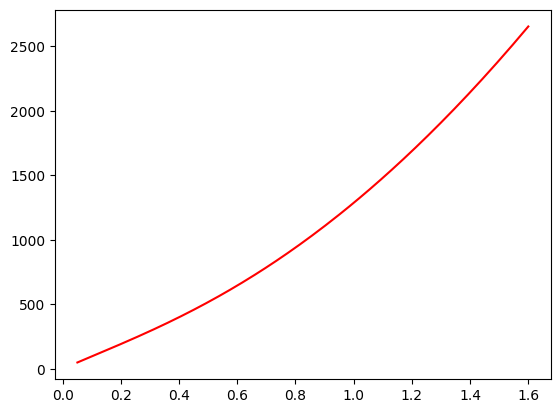

mu_b jump at transition: 0.023 MeV (should be near 0)
Found matching n_t: 0.4207 n0
Bag constant set to -1.8756e+05 fm^-4
0.06798690817833909
0.06907457627223675
0.07017964509686596
0.07130239303258168
0.07244310291332308
0.0736020620978631
0.07477956254219754
0.07597590087309238
0.07719137846280753
0.07842630150501646
0.07968098109193995
0.0809557332927141
0.08225087923301187
0.08356674517593879
0.08490366260422247
0.08626196830371725
0.08764200444824452
0.08904411868579065
0.09046866422608377
0.09191599992957153
0.09338649039782237
0.09488050606537339
0.09639842329304707
0.09794062446276133
0.09950749807385602
0.10109943884096091
0.10271684779342898
0.10436013237636065
0.10602970655324415
0.107725990910238
0.1094494127621219
0.11120040625994247
0.11297941250038117
0.11478687963687198
0.11662326299249681
0.1184890251746869
0.12038463619175922
0.1223105735713174
0.12426732248054678
0.12625537584843396
0.12827523448994152
0.13032740723216957
0.13241241104253554
0.13453077115900447
0.136

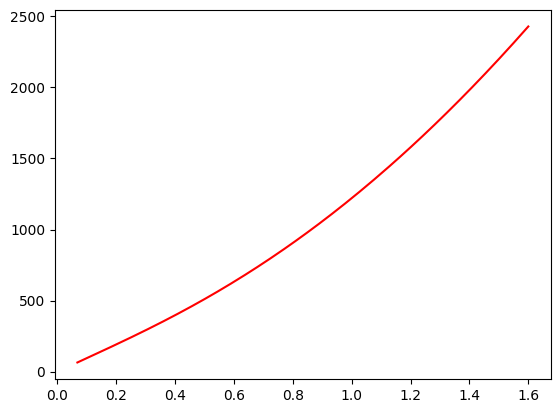

mu_b jump at transition: 0.070 MeV (should be near 0)
Found matching n_t: 0.2942 n0
Bag constant set to -2.7463e+05 fm^-4
0.04753970409685009
0.0483871630615008
0.04924972911843179
0.050127671571817814
0.0510212645265417
0.0519307869737733
0.05285652287807411
0.05379876126605471
0.05475779631661242
0.05573392745277794
0.056727459435198926
0.057738702457290104
0.058767972242079795
0.05981559014078259
0.06088188323312932
0.061967184429485594
0.06307183257479054
0.06419617255434874
0.06534055540150771
0.06650533840725496
0.067690885231769
0.06889756601795854
0.07012575750702592
0.07137584315609058
0.07264821325790911
0.0739432650627299
0.07526140290231961
0.07660303831620066
0.07796859018013932
0.079358484836924
0.0807731562294749
0.08221304603632665
0.08367860380952581
0.08517028711498703
0.08668856167535088
0.0882339015153883
0.08980678910999741
0.09140771553483829
0.09303718061965302
0.09469569310431905
0.09638377079768409
0.09810194073923299
0.09985073936363602
0.10163071266823051
0.1

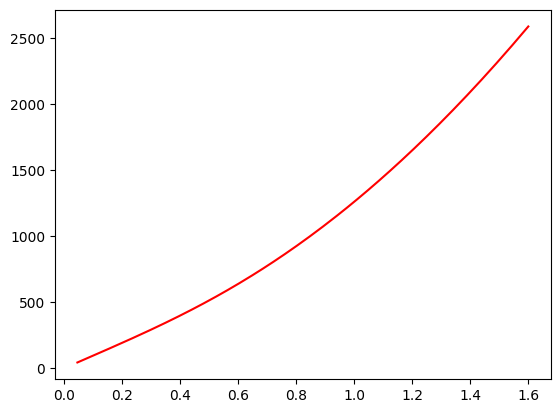

mu_b jump at transition: 1.450 MeV (should be near 0)


In [3]:
RMFT_PARAMS_1 = [7.54,8.43,10.88,0.0073,0.0035,7.89,0.0,mn/hc]
RMFT_PARAMS_2 = [7.82,8.99,11.24,0.0063,-0.0009,8.02,0.0,mn/hc]
RMFT_PARAMS_3 = [8.32,9.76,12.18,0.0063,-0.006,5.87,0.0,mn/hc]
RMFT_PARAMS_4 = [8.21,9.94,12.18,0.0041,-0.0021,10.43,0.0,939.56/hc]

RMFT_EOS1_Finite_T_1 = RMFT_Finite_T(RMFT_PARAMS_1,T=0.0,leptons_present=True)
RMFT_EOS1_Finite_T_1.attach_compose_crust('/home/john/UW_PhD_Program/Projects/2025/RVSS_Slope_Parametrization/EOS_Tables/GPPVA',n_t = 0.4*n_0)
RMFT_EOS1_Finite_T_4 = RMFT_Finite_T(RMFT_PARAMS_4,T=0.0,leptons_present=True)
RMFT_EOS1_Finite_T_4.attach_compose_crust('/home/john/UW_PhD_Program/Projects/2025/RVSS_Slope_Parametrization/EOS_Tables/GPPVA',n_t = 0.4*n_0)
RMFT_EOS1_Finite_T_2 = RMFT_Finite_T(RMFT_PARAMS_2,T=0.0,leptons_present=True)
RMFT_EOS1_Finite_T_2.attach_compose_crust('/home/john/UW_PhD_Program/Projects/2025/RVSS_Slope_Parametrization/EOS_Tables/GPPVA',n_t = 0.4*n_0)
RMFT_EOS1_Finite_T_3 = RMFT_Finite_T(RMFT_PARAMS_3,T=0.0,leptons_present=True)
RMFT_EOS1_Finite_T_3.attach_compose_crust('/home/john/UW_PhD_Program/Projects/2025/RVSS_Slope_Parametrization/EOS_Tables/GPPVA',n_t = 0.4*n_0)


In [4]:
eos_interp_1 = PchipInterpolator(RMFT_EOS1_Finite_T_1.P_combined,RMFT_EOS1_Finite_T_1.e_combined)
dens_interp_1 = PchipInterpolator(RMFT_EOS1_Finite_T_2.P_combined,RMFT_EOS1_Finite_T_2.nb_combined)
cs2_interp_1 = lambda p: 1/eos_interp_1.derivative()(p)
cs2_1 = cs2_interp_1(RMFT_EOS1_Finite_T_1.P_combined)

eos_interp_2 = PchipInterpolator(RMFT_EOS1_Finite_T_2.P_combined,RMFT_EOS1_Finite_T_2.e_combined)
dens_interp_2 = PchipInterpolator(RMFT_EOS1_Finite_T_2.P_combined,RMFT_EOS1_Finite_T_2.nb_combined)
cs2_interp_2 = lambda p: 1/eos_interp_2.derivative()(p)
cs2_2 = cs2_interp_2(RMFT_EOS1_Finite_T_2.P_combined)

eos_interp_3 = PchipInterpolator(RMFT_EOS1_Finite_T_3.P_combined,RMFT_EOS1_Finite_T_3.e_combined)
dens_interp_3 = PchipInterpolator(RMFT_EOS1_Finite_T_3.P_combined,RMFT_EOS1_Finite_T_3.nb_combined)
cs2_interp_3 = lambda p: 1/eos_interp_3.derivative()(p)
cs2_3 = cs2_interp_3(RMFT_EOS1_Finite_T_3.P_combined)

eos_interp_4 = PchipInterpolator(RMFT_EOS1_Finite_T_4.P_combined,RMFT_EOS1_Finite_T_4.e_combined)
dens_interp_4 = PchipInterpolator(RMFT_EOS1_Finite_T_4.P_combined,RMFT_EOS1_Finite_T_4.nb_combined)
cs2_interp_4 = lambda p: 1/eos_interp_4.derivative()(p)
cs2_4 = cs2_interp_4(RMFT_EOS1_Finite_T_4.P_combined)

muB_cs2_interp1 = PchipInterpolator(RMFT_EOS1_Finite_T_1.muB_combined,cs2_1)
muB_cs2_interp2 = PchipInterpolator(RMFT_EOS1_Finite_T_2.muB_combined,cs2_2)
muB_cs2_interp3 = PchipInterpolator(RMFT_EOS1_Finite_T_3.muB_combined,cs2_3)
muB_cs2_interp4 = PchipInterpolator(RMFT_EOS1_Finite_T_4.muB_combined,cs2_4)


muB_cs2_deriv1 = muB_cs2_interp1.derivative()(RMFT_EOS1_Finite_T_1.muB_combined)
muB_cs2_deriv2 = muB_cs2_interp2.derivative()(RMFT_EOS1_Finite_T_2.muB_combined)
muB_cs2_deriv3 = muB_cs2_interp3.derivative()(RMFT_EOS1_Finite_T_3.muB_combined)
muB_cs2_deriv4 = muB_cs2_interp4.derivative()(RMFT_EOS1_Finite_T_4.muB_combined)

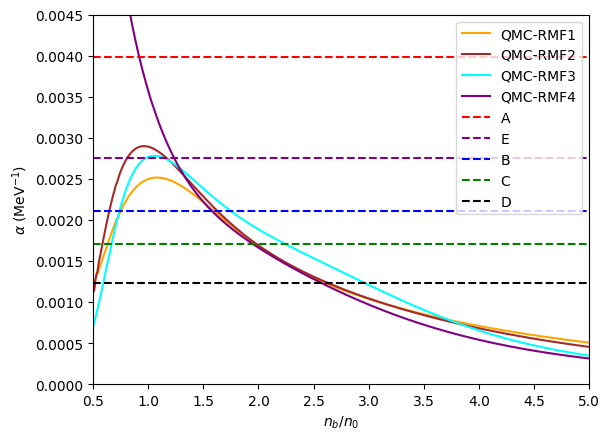

In [6]:
# plt.plot(ls220_nb/n0,alpha_ls220,color = 'purple',label='LS220')
# plt.plot(sfho_nb/n0,alpha_sfho,color='brown',label='SFHO')
# plt.plot(bhb_nb/n0,alpha_bhb,color='green',label='BHB')
# plt.plot(bl_nb/n0,alpha_bl,color='orange',label='BL')
plt.plot(RMFT_EOS1_Finite_T_1.nb_combined/n_0,muB_cs2_deriv1,'orange',label='QMC-RMF1') 
plt.plot(RMFT_EOS1_Finite_T_2.nb_combined/n_0,muB_cs2_deriv2,'brown',label='QMC-RMF2') 
plt.plot(RMFT_EOS1_Finite_T_3.nb_combined/n_0,muB_cs2_deriv3,'cyan',label='QMC-RMF3') 
plt.plot(RMFT_EOS1_Finite_T_4.nb_combined/n_0,muB_cs2_deriv4,'purple',label='QMC-RMF4')
plt.axhline(y = 0.003985692037555738,color='red',linestyle = '--',label='A')
plt.axhline(y=0.00276,color='purple',linestyle = '--',label='E')
plt.axhline(y = 0.002112742893851452,color='blue',linestyle = '--',label='B')
plt.axhline(y = 0.0017107796622185417,color='green',linestyle='--',label='C')
plt.axhline(y = 0.0012392345966394309,color='black',linestyle='--',label='D')
plt.ylim([0,0.0045])
plt.xlim([0.5,5])
plt.xlabel(r'$n_b/n_0$')
plt.ylabel(r'$\alpha$ ($\text{MeV}^{-1}$)')
plt.legend()
plt.savefig('./Figures/T2 Seminar Figs/alpha_nb_RMFT_comparison.pdf',format='pdf')

In [13]:
eosA = rvss_eos(1200,mu_max=2700)
eosB = rvss_eos(1400,mu_max=2700)
eosC = rvss_eos(1500,mu_max=2700)
eosD = rvss_eos(1700,mu_max=2700)

nb = np.linspace(0,5*n0,300)

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2025/RVSS_Slope_Parametrization/RVSS_EOS_Slope.py:106: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [15]:
eosA_cs2_nb = eosA.cs2_nb(nb)
eosB_cs2_nb = eosB.cs2_nb(nb)
eosC_cs2_nb = eosC.cs2_nb(nb)
eosD_cs2_nb = eosD.cs2_nb(nb)

In [17]:
NS_markers_nc_1p3 = [0.28665215919258796,0.40375337689245755,0.4758254634177245,0.672727601030774]
NS_markers_nc_1p4 = [0.29314537329268486,0.42331461778313034,0.5069602976208191,0.7521307797427869]

NS_markers_cs2_1p3 = [eosA.cs2_nb(NS_markers_nc_1p3[0]),eosB.cs2_nb(NS_markers_nc_1p3[1]),eosC.cs2_nb(NS_markers_nc_1p3[2]),eosD.cs2_nb(NS_markers_nc_1p3[3])]
NS_markers_cs2_1p4 = [eosA.cs2_nb(NS_markers_nc_1p4[0]),eosB.cs2_nb(NS_markers_nc_1p4[1]),eosC.cs2_nb(NS_markers_nc_1p4[2]),eosD.cs2_nb(NS_markers_nc_1p4[3])]

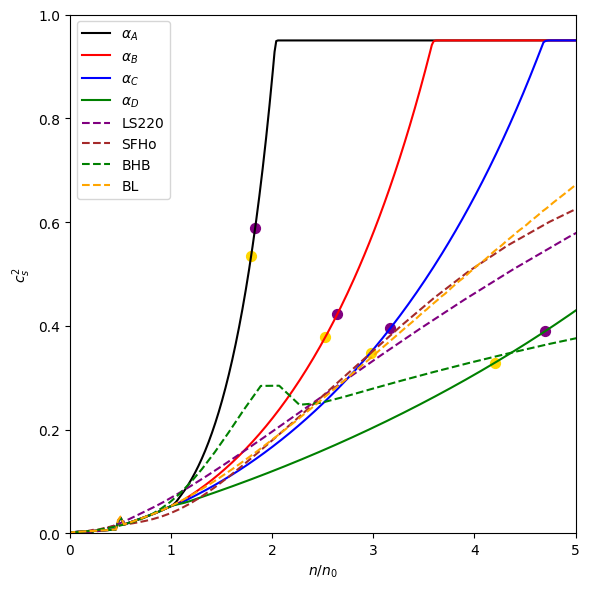

In [24]:
plt.figure(figsize=(6,6))
#plt.gca().set_aspect('equal',adjustable='box')
plt.scatter(np.asarray(NS_markers_nc_1p3)/n0,NS_markers_cs2_1p3,50,'gold')
plt.scatter(np.asarray(NS_markers_nc_1p4)/n0,NS_markers_cs2_1p4,50,'purple')
plt.plot(nb/n0,eosA_cs2_nb,'black',label=r'$\alpha_A$')
plt.plot(nb/n0,eosB_cs2_nb,'red',label=r'$\alpha_B$')
plt.plot(nb/n0,eosC_cs2_nb,'blue',label=r'$\alpha_C$')
plt.plot(nb/n0,eosD_cs2_nb,'green',label=r'$\alpha_D$')


plt.plot(ls220_nb/n0,ls220_cs2,'purple',linestyle='--',label='LS220')
plt.plot(sfho_nb/n0,sfho_cs2,'brown',linestyle='--',label='SFHo')
plt.plot(bhb_nb/n0,bhb_cs2,'green',linestyle='--',label='BHB')
plt.plot(bl.nb/n0,bl_cs2,'orange',linestyle='--',label='BL')


plt.xlim([0,5])
plt.ylim([0,1])
plt.ylabel(r'$c_s^2$')
plt.xlabel(r'$n/n_0$')
plt.legend()
plt.tight_layout()


plt.savefig('./Figures/cs2_nb_alpha.png',dpi=300)